In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler ,OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0


In [3]:
num_of_na=df.isna().sum()
print(num_of_na)
num_of_dub=df.duplicated().sum()
print(num_of_dub)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64
720


In [4]:
df.dropna(inplace=True)

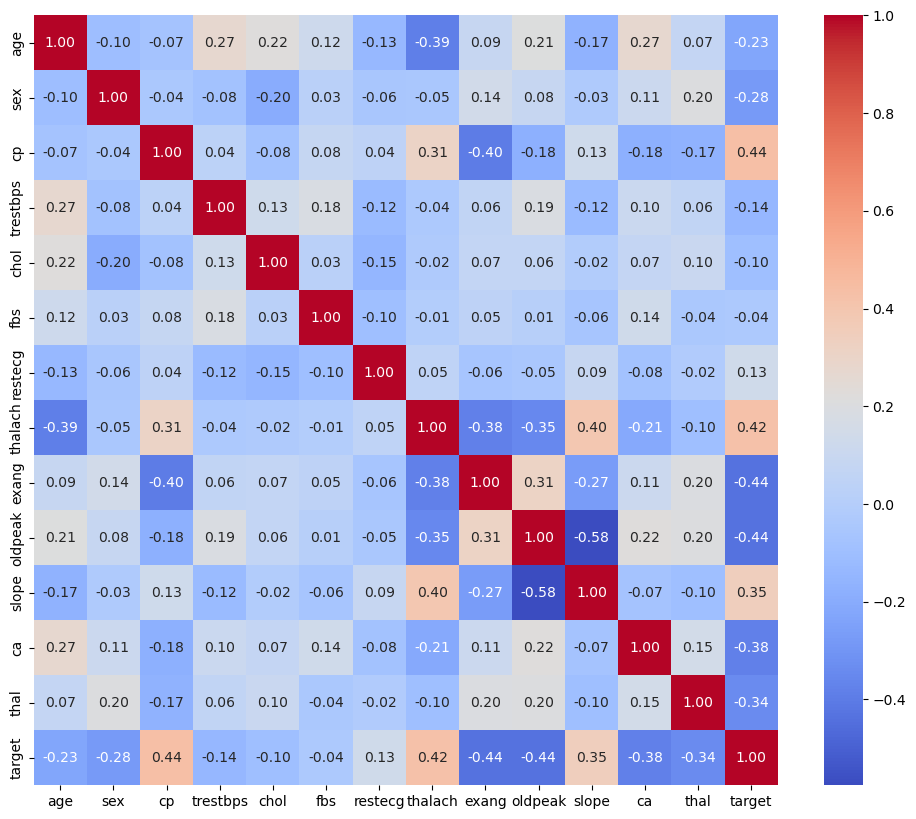

In [5]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [6]:
df.drop(columns=['trestbps','fbs','chol', 'restecg'], inplace=True)
num_cols = ['age','thalach','oldpeak']
cat_cols = ['sex', 'cp', 'exang', 'slope', 'ca', 'thal']

In [7]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [8]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_cat = encoder.fit_transform(df[cat_cols])
encoded_cat_df = pd.DataFrame(encoded_cat, columns=encoder.get_feature_names_out(cat_cols))
df = pd.concat([df.drop(columns=cat_cols), encoded_cat_df], axis=1)
df.head()

,age,thalach,oldpeak,target,sex_0,sex_1,cp_0,cp_1,cp_2,cp_3,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.479167,0.740458,0.161290,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.500000,0.641221,0.500000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.854167,0.412214,0.419355,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.666667,0.687023,0.000000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.687500,0.267176,0.306452,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [9]:
df.to_csv("clean_data_duplicates.csv", index=False)